In [1]:
import os
import sys
import pickle
import argparse
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import loguniform

sys.path.insert(1, 'scripts')
sys.path.insert(1, 'stella')

import stella

2025-01-22 15:05:19.495994: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/astro/phrdhx/micromamba/envs/nets2/lib/python3.8/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /home/astro/phrdhx/.lightkurve/cache. Please move all the files in the legacy directory /home/astro/phrdhx/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


## Load dataset

In [2]:
with open("../datasets/comets-plus-extras-opt.pkl", "rb") as file:
    ds = pickle.load(file)

In [3]:
data = ds['dataset']

In [4]:
cnn = stella.ConvNN(
    output_dir='../cnn-models/',
    ds=data)

In [7]:
cnn.load_model('../cnn-models/ensemble_s0021_i0200_b0.81.h5')

313/313 [==============================] - 1s 2ms/step


NameError: name 'idx' is not defined

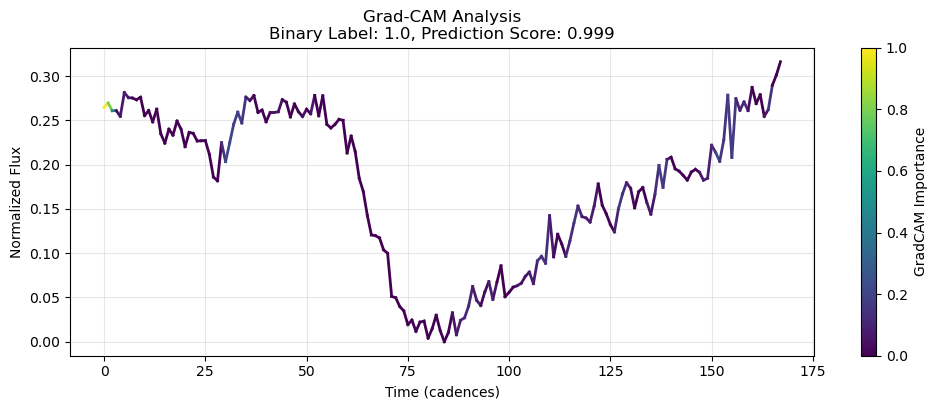

In [8]:
layer_name = 'conv1d'

# Select some example indices to analyze
# For example, let's look at 5 examples each of exocomets and non-exocomets
exocomet_indices = np.where(cnn.ds.val_labels == 1)[0][:25]
#non_exocomet_indices = np.where(cnn.ds.val_labels == 0)[0][:25]
#example_indices = np.concatenate([exocomet_indices, non_exocomet_indices])

# Create output directory for GradCAM visualizations
output_dir = "gradcam_results"
os.makedirs(output_dir, exist_ok=True)

# Run GradCAM analysis
cnn.gradcam_analysis(
    layer_name=layer_name,
    example_indices=exocomet_indices,
    save_path=output_dir,
    dataset='validation',
    use_original_labels=False  # Set to True if you want to see original class labels
)